# Evaluation / Comparaison & Model Improvement

In [157]:
import pandas as pd
import pickle
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, log_loss
import matplotlib.pyplot as plt

df = pd.read_csv('/Users/baptistesmac/Documents/Formation finance/ML ligue 1/data/ligue1_features2.csv')

with open('/Users/baptistesmac/Documents/Formation finance/ML ligue 1/models/model_rf2.pkl', 'rb') as f:
    model_rf = pickle.load(f)

## 1. Game Prediction - Concret example

First, let's try to predict a match during this current season.
What would our model have predicted for the Rennes-Metz game on the 22/03/2026 ? 

In [158]:
cols_to_exclude = [
    'season', 'date', 'home_team', 'away_team',
    'home_goals', 'away_goals',
    'home_xg', 'away_xg',
    'home_shots', 'away_shots',
    'home_shots_on_target', 'away_shots_on_target',
    'home_ppda', 'away_ppda',
    'home_deep', 'away_deep',
    'Result', 'target'
]
feature_cols = [c for c in df.columns if c not in cols_to_exclude]

df_2526 = df[df['season'] == '2025/26'].dropna(subset=feature_cols)

#Selection of our game
match = df_2526[
    (df_2526['home_team'] == 'Rennes') &
    (df_2526['away_team'] == 'Metz') &
    (df_2526['date'] == '2026-03-22')
]

X_match = match.drop(columns=cols_to_exclude)

proba = model_rf.predict_proba(X_match)[0]
classes = model_rf.classes_  # [0, 1, 2] = [H, D, A]

print(f"Home win ({match['home_team'].values[0]}) : {proba[0]:.1%}")
print(f"Draw : {proba[1]:.1%}")
print(f"Away win ({match['away_team'].values[0]}) : {proba[2]:.1%}")
print(f"\nActual Result : {match['Result'].values[0]}")

Home win (Rennes) : 61.3%
Draw : 24.0%
Away win (Metz) : 14.7%

Actual Result : D


The model predicted a home win (61.3% H) but the actual result was a draw. This is consistent
with our confusion matrix findings — the model systematically misclassifies draws as home wins
when the home team is favoured on paper. Rennes' points advantage and superior recent xG
masked the possibility of a competitive draw, which is exactly the blind spot our model cannot
address without draw-specific features.

## 2. Evaluation of our model

### Comparaison with Bookmakers' odds

Let's import the bookmakers' odds of our 5 seasons matches to compare those to our model.
Source : https://www.football-data.co.uk/francem.php
The odds are the columns B365H , B365D, B365A

The idea is to compare to probability of wins to those of bookmakers. It will gives us a good idea of our good our model is, and, maybe, potential arbitrary ...

In [159]:
df_odds = pd.read_csv('/Users/baptistesmac/Documents/Formation finance/ML ligue 1/data/Odds_24:25.csv') 

#We need to redefine the name of the teams in odds.csv to match with our data

team_mapping = {
    'Paris SG': 'Paris Saint Germain',
    'St Etienne': 'Saint-Etienne',
}
df_odds['HomeTeam'] = df_odds['HomeTeam'].replace(team_mapping)
df_odds['AwayTeam'] = df_odds['AwayTeam'].replace(team_mapping)
df_odds['date'] = pd.to_datetime(df_odds['Date'], format='%d/%m/%Y').dt.strftime('%Y-%m-%d')

First : conversion of odds to probabilities

In [160]:
df_odds['raw_H'] = 1 / df_odds['B365H']
df_odds['raw_D'] = 1 / df_odds['B365D']
df_odds['raw_A'] = 1 / df_odds['B365A']

df_odds['overround'] = df_odds['raw_H'] + df_odds['raw_D'] + df_odds['raw_A']
print(df_odds['overround'].iloc[:5])
#The sum exceeds 1 : it is due to the bookmaker's margin
#So we need to normalize it : 

df_odds['new_H'] = df_odds['raw_H'] / df_odds['overround']
df_odds['new_D'] = df_odds['raw_D'] / df_odds['overround']
df_odds['new_A'] = df_odds['raw_A'] / df_odds['overround']



0    1.057609
1    1.053030
2    1.051693
3    1.057898
4    1.055805
Name: overround, dtype: float64


Now : computation of our probabilities

In [161]:
test_clean = df[df['season'] == '2024/25'].dropna(subset=feature_cols)
X_test_full = test_clean.drop(columns=cols_to_exclude)
probas = model_rf.predict_proba(X_test_full)

test_clean = test_clean.copy()
test_clean['model_H'] = probas[:, 0]
test_clean['model_D'] = probas[:, 1]
test_clean['model_A'] = probas[:, 2]

# Merger avec les cotes — ajuste les noms de colonnes selon ton CSV
df_merged = test_clean.merge(
    df_odds[['date', 'HomeTeam', 'AwayTeam', 'new_H', 'new_D', 'new_A']],
    left_on=['date', 'home_team', 'away_team'],
    right_on=['date', 'HomeTeam', 'AwayTeam'],
    how='inner'
)


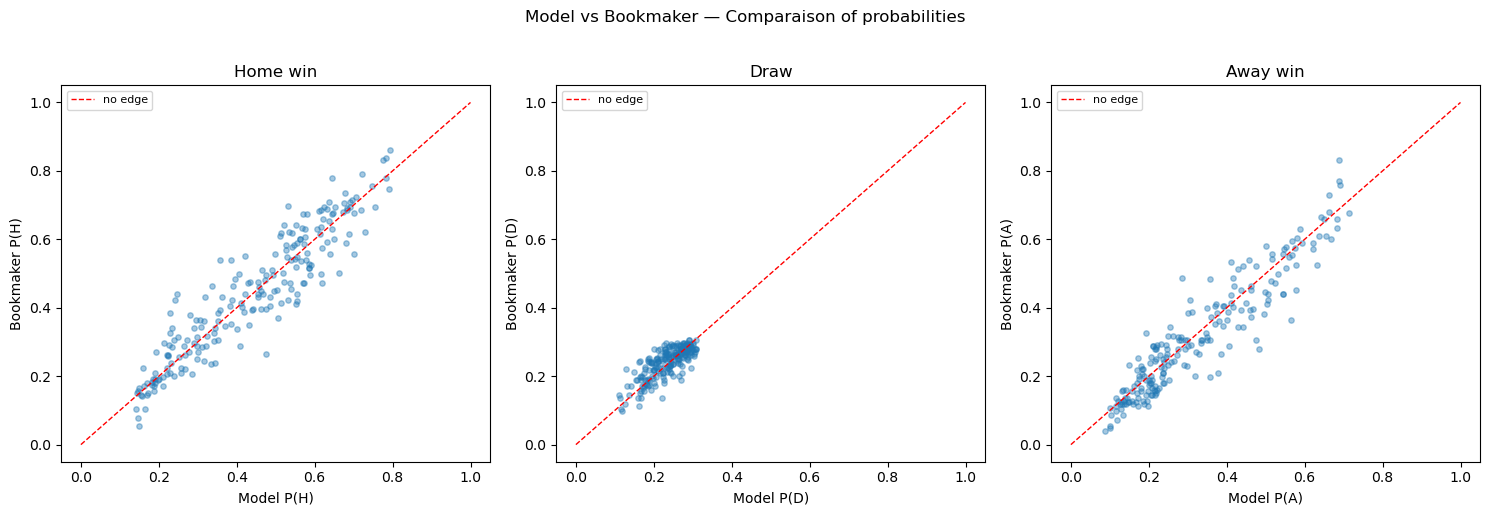

In [162]:

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
outcomes = [('H', 'Home win'), ('D', 'Draw'), ('A', 'Away win')]

for ax, (outcome, title) in zip(axes, outcomes):
    ax.scatter(
        df_merged[f'model_{outcome}'],
        df_merged[f'new_{outcome}'],
        alpha=0.4, s=15
    )
    # Ligne diagonale — si les points sont dessus, pas d'edge
    ax.plot([0, 1], [0, 1], 'r--', linewidth=1, label='no edge')
    ax.set_xlabel(f'Model P({outcome})')
    ax.set_ylabel(f'Bookmaker P({outcome})')
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.suptitle('Model vs Bookmaker — Comparaison of probabilities', y=1.02)
plt.tight_layout()
plt.show()

In [163]:
df_merged['bookie_pred'] = df_merged[['new_H', 'new_D', 'new_A']].values.argmax(axis=1)

# Accuracy bookmaker
acc_bookie = accuracy_score(df_merged['target'], df_merged['bookie_pred'])

# Log-loss bookmaker
bookie_probas = df_merged[['new_H', 'new_D', 'new_A']].values
ll_bookie = log_loss(df_merged['target'], bookie_probas)

model_probas = df_merged[['model_H', 'model_D', 'model_A']].values
model_preds  = model_probas.argmax(axis=1)
acc_model = accuracy_score(df_merged['target'], model_preds)
ll_model  = log_loss(df_merged['target'], model_probas)

print(f"{'':25} Accuracy   Log-loss")
print(f"{'Bookmaker (Bet365)':25} {acc_bookie:.3f}      {ll_bookie:.3f}")
print(f"{'Random Forest':25} {acc_model:.3f}      {ll_model:.3f}")

                          Accuracy   Log-loss
Bookmaker (Bet365)        0.550      0.953
Random Forest             0.569      0.957


In [164]:
for outcome in ['H', 'D', 'A']:
    mae = (df_merged[f'model_{outcome}'] - df_merged[f'new_{outcome}']).abs().mean()*100
    print(f"Mean average error {outcome} : {mae:.3f}:%")

Mean average error H : 5.259:%
Mean average error D : 2.487:%
Mean average error A : 4.664:%


For each of the 211 test matches (season 2024/25), we now have two probability estimates side by side :
- **Our model** (Random Forest) → `model_H`, `model_D`, `model_A`
- **Bet365 implied probabilities** → normalized from `B365H`, `B365D`, `B365A`

Our model achieves comparable accuracy to Bet365 on this test set (56.9% vs 55.0%), 
but Bet365 maintains a better log-loss (0.953 vs 0.957), confirming that the market 
produces better-calibrated probabilities. The accuracy gap (4 matches over 211) is 
not statistically significant. Tt means we have
both reached the natural predictability ceiling of football, which sits around 55-60%
regardless of the information available. The sport is inherently random.

 Bookmakers gain money via their overround, not via prediction accuracy. They are not aiming to optimize their accuracy, but just to ensure an overround in their odds.

The main structural difference: our model compresses draw probabilities into a 
narrow 25-28% band regardless of the match context, while Bet365 prices draws 
between 20% and 38%. This suggests the bookmaker has access to information 
(team news, tactical context, market flows) that our statistical features cannot capture.

### Is our model really relevant  ? 

If we just say "the team with the highest championship points will win", that is by considering only the total points variable, do we get a better result ? 

In [165]:
test_naive = df[df['season'] == '2024/25'].dropna(subset=feature_cols).copy()


def naive_predict(points_diff):
    if points_diff > 0:
        return 0  # H
    elif points_diff < 0:
        return 2  # A
    else:
        return 1  # D (égalité de points)

test_naive['naive_pred'] = test_naive['points_diff'].apply(naive_predict)

acc_naive = accuracy_score(test_naive['target'], test_naive['naive_pred'])
print(f"Accuracy naive (points_diff only) : {acc_naive:.3f}")
print(f"Accuracy Random Forest            : 0.569")
print(f"Value of the model                   : {0.569 - acc_naive:+.3f}")

Accuracy naive (points_diff only) : 0.545
Accuracy Random Forest            : 0.569
Value of the model                   : +0.024


**Rule-based baseline** : predict H if points_diff > 0, A otherwise → **54.5% accuracy**

### What this tells us

| Model | Accuracy |
|-------|----------|
| Random (33%) | 0.330 |
| Naive rule (points_diff only) | 0.545 |
| Random Forest (all features) | 0.569 |

The full model adds **+ 2.4%** above the naive baseline. This confirms that our additional
features (market values, xG rolling, PPDA, winrate differentials) carry predictive signal — even if modest.

The gap between naive and full model would widen significantly with more data (additional seasons
or leagues), where complex models can better exploit subtle patterns.